<a href="https://colab.research.google.com/github/MohHaroon/XAI-based-ZSL-for-IIDS/blob/master/ZSAL_and_SOAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementation of the Zero-Shot Attribution Layer and SHAP Overlap Automation Model (SOAM)

## Load CatBoost model and data splits

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Reloading CatBoost
from catboost import CatBoostClassifier
loaded_cat = CatBoostClassifier()
loaded_cat.load_model('/content/drive/MyDrive/IRP_Models/catboost_sdn_20260123_040438.cbm')

In [ ]:
import os
import joblib
import pandas as pd

base_path = '/content/drive/MyDrive/IRP_Models/'
split_path = os.path.join(base_path, 'Data_Splits/')

X_train = joblib.load(os.path.join(split_path, f'X_train.pkl'))
X_test = joblib.load(os.path.join(split_path, f'X_test.pkl'))
y_train = joblib.load(os.path.join(split_path, f'y_train.pkl'))
y_test = joblib.load(os.path.join(split_path, f'y_test.pkl'))


# Adding the column names
feature_names = ["proto_number", "Dur", "Mean", "Stddev", "Min", "Max", "Pkts", "Bytes",
                 "Spkts", "Dpkts", "Sbytes", "Dbytes", "Srate", "Drate", "Sum",
                 "TnBPSrcIP", "TnBPDstIP", "TnP_PSrcIP", "TnP_PDstIP", "TnP_PerProto",
                 "TnP_Per_Dport", "N_IN_Conn_P_DstIP", "N_IN_Conn_P_SrcIP"]

X_test = pd.DataFrame(X_test, columns=feature_names)
X_train = pd.DataFrame(X_train, columns=feature_names)

print(f"\nSuccessfully loaded Data Splits for {len(X_test)} test packets.")


Successfully loaded Data Splits for 42000 test packets.


## Zero-Shot Attribution Layer (ZSAL)

### Generating SHAP values and plot

Monitoring SDN Traffic...
ALARM: Anomaly detected at packet index 0


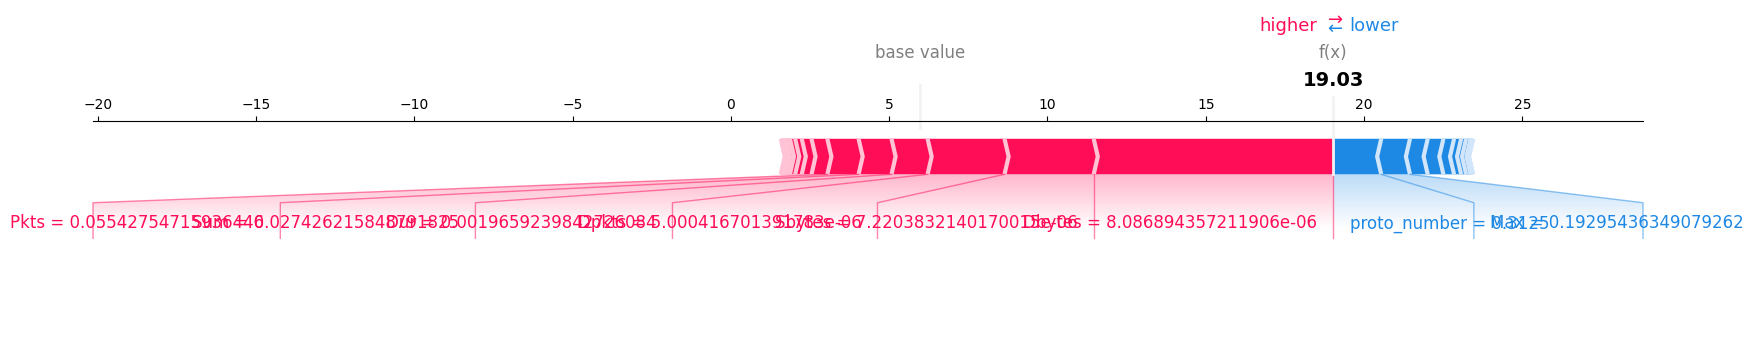

In [46]:
import shap

# Initialize Explainer
explainer = shap.TreeExplainer(loaded_cat)

# Simulating SDIN Monitoring
print("Monitoring SDN Traffic...")
found_anomaly = False

for i in range(len(X_test)):
    # Get a single packet instance
    instance = X_test.iloc[i:i+1]

    # Inference
    prediction = loaded_cat.predict(instance)[0]

    if prediction == 1:  # Anomaly
        print(f"ALARM: Anomaly detected at packet index {i}")

        # Generate SHAP values
        instance_shap = explainer.shap_values(instance)

        shap.force_plot(explainer.expected_value, instance_shap[0], instance, matplotlib=True)

        # for ZSAL Labeling
        target_instance = instance
        target_shap = instance_shap[0]
        found_anomaly = True
        break

if not found_anomaly:
    print("No anomalies detected in the current traffic batch.")

In [44]:
print(instance)

   proto_number       Dur      Mean    Stddev       Min       Max      Pkts  \
0        0.3125  0.001966  0.029177  0.121601  0.000411  0.192954  0.055428   

      Bytes     Spkts     Dpkts  ...     Drate       Sum  TnBPSrcIP  \
0  0.052419  0.000008  0.000005  ...  0.000012  0.027426   0.058714   

   TnBPDstIP  TnP_PSrcIP  TnP_PDstIP  TnP_PerProto  TnP_Per_Dport  \
0   0.041362    0.056576    0.056573      0.055426       0.016501   

   N_IN_Conn_P_DstIP  N_IN_Conn_P_SrcIP  
0           0.000043           0.000102  

[1 rows x 23 columns]


In [47]:
print(target_shap)

[-1.51216400e+00  1.13995426e+00 -1.38686255e-01 -2.22529640e-01
 -8.70683341e-04 -9.08581498e-01  9.87232053e-01 -3.37505351e-01
  2.06964538e-01  2.43054045e+00  2.81709370e+00  7.57021343e+00
  9.14810218e-02 -4.95600218e-01  1.04016687e+00  1.65754870e-01
  7.82980058e-02  5.00120688e-01 -1.58382783e-01  1.22069291e-01
  3.08664532e-01 -7.86516621e-02 -5.59460870e-01]


In [48]:
print(instance_shap)

[[-1.51216400e+00  1.13995426e+00 -1.38686255e-01 -2.22529640e-01
  -8.70683341e-04 -9.08581498e-01  9.87232053e-01 -3.37505351e-01
   2.06964538e-01  2.43054045e+00  2.81709370e+00  7.57021343e+00
   9.14810218e-02 -4.95600218e-01  1.04016687e+00  1.65754870e-01
   7.82980058e-02  5.00120688e-01 -1.58382783e-01  1.22069291e-01
   3.08664532e-01 -7.86516621e-02 -5.59460870e-01]]


In [49]:
print(explainer.expected_value)

5.984509674509375


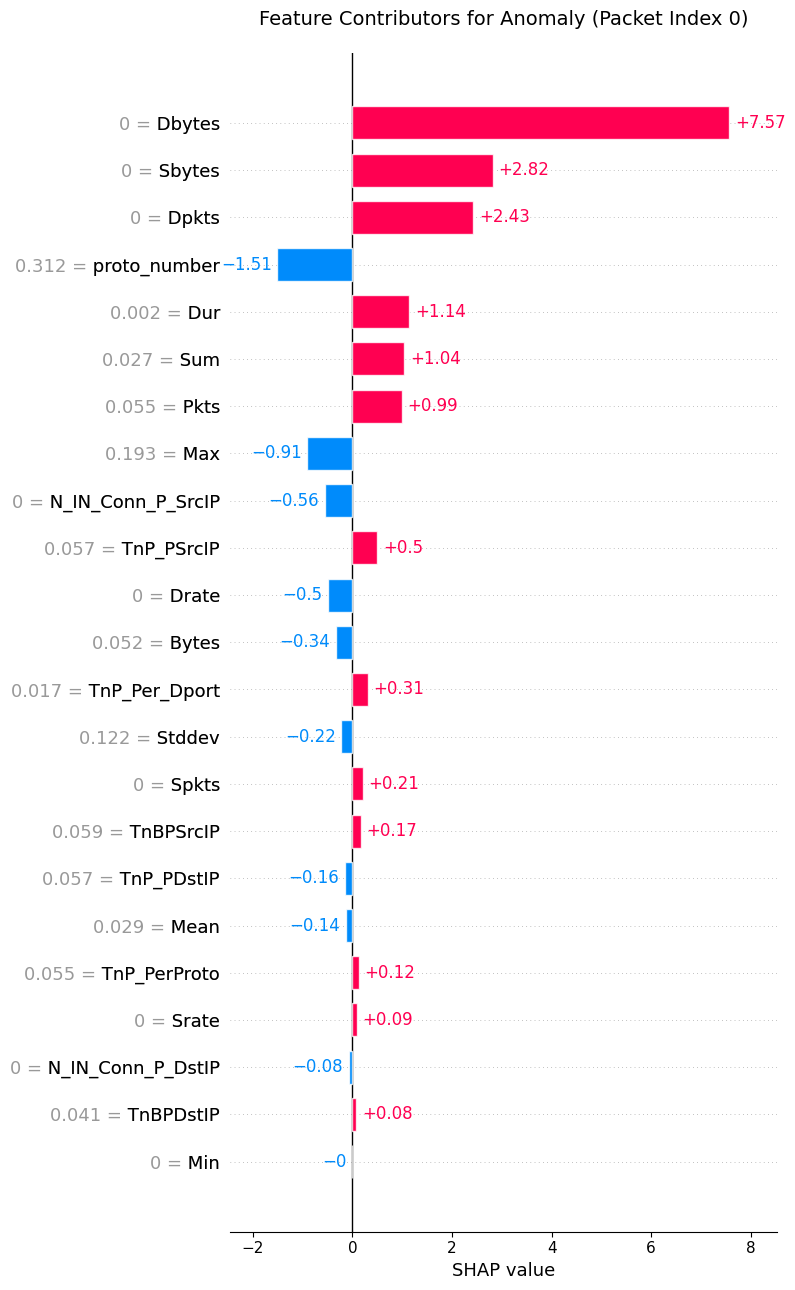

In [43]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

shap_explanation = shap.Explanation(
    values=target_shap,               # The SHAP values for this instance
    base_values=explainer.expected_value, # The average model output
    data=instance.iloc[0],         # The actual feature values for this row
    feature_names=instance.columns
)

plt.figure(figsize=(12, 8))
shap.plots.bar(shap_explanation, max_display=24, show=False)

plt.title(f"Feature Contributors for Anomaly (Packet Index {i})", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### Attribute the Anomaly with a label

In [54]:
def generate_zasl_label(shap_values, feature_names):

    positive_contributions = [(val, name) for val, name in zip(shap_values, feature_names) if val > 0]
    # Sort by impact (highest value first)
    sorted_contributions = sorted(positive_contributions, key=lambda x: x[0], reverse=True)

    # Extract top features
    top_features = [item[1] for item in sorted_contributions[:3]]
    high_impact_extra = [item[1] for item in sorted_contributions[3:] if item[0] > 2]

    final_feature_list = top_features + high_impact_extra

    if not top_features:
        return "Generic Anomaly"

    return f"{'-'.join(final_feature_list)}-based-Attribution"

zasl_name = generate_zasl_label(target_shap, feature_names)
print(f"ZASL Final Label: {zasl_name}")

ZASL Final Label: Dbytes-Sbytes-Dpkts-based-Attribution


## SHAP Overlap Automation Model (SOAM)